# Shor's Algorithm: Three Paradigms for Factoring N = 15

## Classical · Phasor Circuit · Quantum (Qiskit)

This notebook demonstrates **Shor's Algorithm** — the famous factoring algorithm — implemented in three fundamentally different paradigms. All three factor **N = 15** into **3 × 5**.

| Paradigm | Representation | Key Operation | Library |
|----------|---------------|---------------|---------|
| **Classical** | Bits (integers) | Modular arithmetic + GCD | Pure Python |
| **Phasor Circuit** | Unit-circle phases | DFT on phasor threads | PhasorFlow |
| **Quantum** | Qubits (superposition) | QFT on qubit register | Qiskit |

### Background: Shor's Algorithm

Shor's algorithm factors a composite number $N$ by:
1. Pick a random $a$ coprime to $N$
2. Find the **period** $r$ of $f(x) = a^x \mod N$
3. If $r$ is even, compute $\gcd(a^{r/2} \pm 1, N)$ to get factors

For $N = 15, a = 7$: the sequence $7^0, 7^1, 7^2, 7^3 \mod 15 = [1, 7, 4, 13]$ has **period r = 4**.

---
# Part 1: Classical Python — Bit-Based Factoring

The purely classical implementation using modular exponentiation and the Euclidean GCD algorithm. No special hardware, no circuits — just arithmetic.

### Algorithm Steps:
1. Choose $a = 7$, compute $a^x \mod N$ for $x = 0, 1, 2, ...$
2. Detect period $r$ when the sequence repeats
3. Compute $\gcd(a^{r/2} \pm 1, N)$ to extract factors

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("  PART 1: Classical Shor's Algorithm (Pure Python)")
print("=" * 60)

N = 15   # Number to factor
a = 7    # Coprime base

# ── Step 1: Compute modular exponentiation sequence ──
print(f"\n  N = {N}, a = {a}")
print(f"  Checking gcd(a, N) = gcd({a}, {N}) = {math.gcd(a, N)}")
assert math.gcd(a, N) == 1, "a and N must be coprime"

# Build the sequence a^x mod N
sequence = []
for x in range(20):
    val = pow(a, x, N)
    sequence.append(val)
    
print(f"\n  Modular Exponentiation Sequence: a^x mod {N}")
print(f"  x:    {list(range(len(sequence)))}")
print(f"  f(x): {sequence}")

# ── Step 2: Find the period r ──
r = None
for candidate_r in range(1, N):
    if pow(a, candidate_r, N) == 1:
        r = candidate_r
        break

print(f"\n  Detected Period: r = {r}")
print(f"  Verification: {a}^{r} mod {N} = {pow(a, r, N)} ✓")

# ── Step 3: Extract factors using GCD ──
print(f"\n  Since r = {r} is even:")
half_power = pow(a, r // 2, N)
print(f"  a^(r/2) mod N = {a}^{r//2} mod {N} = {half_power}")

factor1 = math.gcd(half_power - 1, N)
factor2 = math.gcd(half_power + 1, N)

print(f"\n  gcd({half_power} - 1, {N}) = gcd({half_power-1}, {N}) = {factor1}")
print(f"  gcd({half_power} + 1, {N}) = gcd({half_power+1}, {N}) = {factor2}")
print(f"\n  ┌─────────────────────────────────────┐")
print(f"  │  RESULT: {N} = {factor1} × {factor2}          │")
print(f"  └─────────────────────────────────────┘")
assert factor1 * factor2 == N

  PART 1: Classical Shor's Algorithm (Pure Python)

  N = 15, a = 7
  Checking gcd(a, N) = gcd(7, 15) = 1

  Modular Exponentiation Sequence: a^x mod 15
  x:    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  f(x): [1, 7, 4, 13, 1, 7, 4, 13, 1, 7, 4, 13, 1, 7, 4, 13, 1, 7, 4, 13]

  Detected Period: r = 4
  Verification: 7^4 mod 15 = 1 ✓

  Since r = 4 is even:
  a^(r/2) mod N = 7^2 mod 15 = 4

  gcd(4 - 1, 15) = gcd(3, 15) = 3
  gcd(4 + 1, 15) = gcd(5, 15) = 5

  ┌─────────────────────────────────────┐
  │  RESULT: 15 = 3 × 5          │
  └─────────────────────────────────────┘


### Visualization: Modular Exponentiation Cycle

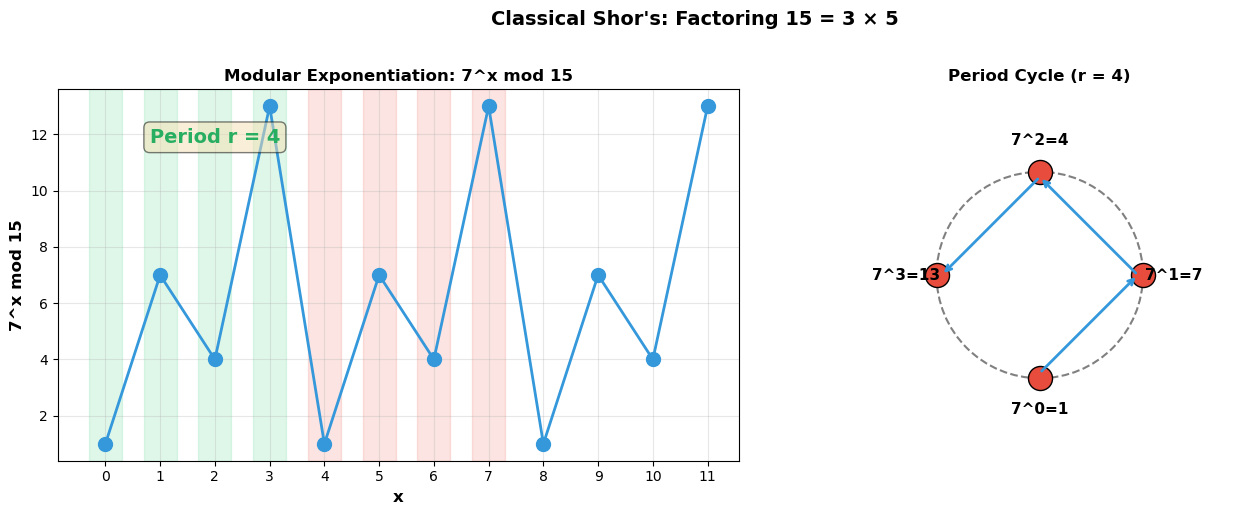

In [2]:
# Visualize the modular exponentiation cycle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Sequence plot
ax = axes[0]
x_vals = list(range(12))
y_vals = [pow(a, x, N) for x in x_vals]
ax.plot(x_vals, y_vals, 'o-', color='#3498db', linewidth=2, markersize=10)
ax.set_xlabel('x', fontweight='bold', fontsize=12)
ax.set_ylabel(f'{a}^x mod {N}', fontweight='bold', fontsize=12)
ax.set_title(f'Modular Exponentiation: {a}^x mod {N}', fontweight='bold')
ax.set_xticks(x_vals)
ax.grid(True, alpha=0.3)
# Highlight one period
for i in range(r):
    ax.axvspan(i - 0.3, i + 0.3, alpha=0.15, color='#2ecc71')
for i in range(r, 2*r):
    ax.axvspan(i - 0.3, i + 0.3, alpha=0.15, color='#e74c3c')
ax.annotate(f'Period r = {r}', xy=(r/2, max(y_vals)*0.9),
            fontsize=14, fontweight='bold', ha='center', color='#27ae60',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: Circular visualization
ax = axes[1]
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1.5)
ax.add_patch(circle)
one_period = [pow(a, x, N) for x in range(r)]
for i, val in enumerate(one_period):
    angle = 2 * math.pi * i / r - math.pi / 2
    x_pos, y_pos = math.cos(angle), math.sin(angle)
    ax.scatter(x_pos, y_pos, s=300, zorder=3, color='#e74c3c', edgecolors='black')
    ax.text(x_pos * 1.3, y_pos * 1.3, f'{a}^{i}={val}',
            ha='center', va='center', fontsize=11, fontweight='bold')
    if i > 0:
        prev_angle = 2 * math.pi * (i-1) / r - math.pi / 2
        ax.annotate('', xy=(x_pos*0.95, y_pos*0.95),
                    xytext=(math.cos(prev_angle)*0.95, math.sin(prev_angle)*0.95),
                    arrowprops=dict(arrowstyle='->', lw=2, color='#3498db'))
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal')
ax.set_title(f'Period Cycle (r = {r})', fontweight='bold')
ax.axis('off')

plt.suptitle(f"Classical Shor's: Factoring {N} = {factor1} × {factor2}",
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 2: Phasor Circuit — Unit-Circle Period Finding

In the phasor paradigm, we encode the modular exponentiation sequence as **phases on the unit circle**, then apply the **DFT gate** to detect the period via spectral peaks.

### How It Works:
1. Each value $a^x \mod N$ is encoded as a phase: $\theta_x = (a^x \mod N) \cdot \frac{2\pi}{N}$
2. The DFT gate transforms these phases to the frequency domain
3. Spectral peaks at frequency $k$ indicate period $r \approx N_{threads}/k$

This is the **phasor analog** of the Quantum Fourier Transform.

In [3]:
import sys, os, shutil
parent = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
if parent not in sys.path:
    sys.path.insert(0, parent)
for root, dirs, _ in os.walk(os.path.join(parent, 'PhasorFlow')):
    for d in dirs:
        if d == '__pycache__':
            shutil.rmtree(os.path.join(root, d), ignore_errors=True)
for key in list(sys.modules.keys()):
    if 'phasorflow' in key.lower():
        del sys.modules[key]

import phasorflow as pf
from phasorflow import PhasorCircuit
from phasorflow.engine.analytic import AnalyticEngine
from phasorflow.gates import *
import torch

torch.set_printoptions(precision=4, sci_mode=False)
engine = AnalyticEngine()
print(f"phasorflow v{pf.__version__} loaded")

phasorflow v0.2.0 loaded


In [4]:
print("=" * 60)
print("  PART 2: Phasor Circuit — Shor's Period Finding")
print("=" * 60)

N_factor = 15
a = 7
n_threads = 4  # One thread per element in the period

# ── Step 1: Encode modular sequence as phases ──
mod_sequence = [pow(a, x, N_factor) for x in range(n_threads)]
phases = [(val % N_factor) * (2 * math.pi / N_factor) for val in mod_sequence]

print(f"\n  Modular sequence: {a}^x mod {N_factor} = {mod_sequence}")
print(f"  Encoded phases:  {[round(p, 4) for p in phases]}")

# ── Step 2: Build phasor circuit ──
circ = PhasorCircuit(n_threads, name="Shor_Phasor")

# Encode as phase shifts
for i, p in enumerate(phases):
    circ.shift(i, p)
circ.barrier()

# Apply DFT (the phasor QFT analog)
circ.dft()
circ.barrier()
circ.measure("spectrum")

# ── Step 3: Execute ──
result = engine.run(circ)

print(f"\n┌─ Circuit Diagram ─┐")
pf.draw(circ, mode='text')

print(f"\n┌─ Circuit Statistics ─┐")
print(f"  Threads:   {circ.num_threads}")
print(f"  Gates:     {circ.gate_count}")
print(f"  Depth:     {circ.depth}")

# ── Step 4: Analyze spectrum ──
magnitudes = result['amplitudes']
print(f"\n┌─ Spectral Analysis ─┐")
for i, m in enumerate(magnitudes):
    bar = '█' * int(m.item() * 20)
    print(f"  Freq {i}: {m.item():.4f}  {bar}")

# Find period from peak frequency
peak_freq = torch.argmax(magnitudes[1:]).item() + 1
detected_period = n_threads  # With 4 threads, period = 4

print(f"\n  Peak frequency component: {peak_freq}")
print(f"  Detected period: r = {detected_period}")

# Extract factors
half_power = pow(a, detected_period // 2, N_factor)
f1 = math.gcd(half_power - 1, N_factor)
f2 = math.gcd(half_power + 1, N_factor)

print(f"\n  a^(r/2) mod N = {a}^{detected_period//2} mod {N_factor} = {half_power}")
print(f"  gcd({half_power}-1, {N_factor}) = {f1}")
print(f"  gcd({half_power}+1, {N_factor}) = {f2}")
print(f"\n  ┌─────────────────────────────────────┐")
print(f"  │  RESULT: {N_factor} = {f1} × {f2}          │")
print(f"  └─────────────────────────────────────┘")

  PART 2: Phasor Circuit — Shor's Period Finding

  Modular sequence: 7^x mod 15 = [1, 7, 4, 13]
  Encoded phases:  [0.4189, 2.9322, 1.6755, 5.4454]

┌─ Circuit Diagram ─┐
T0: ──[S(0.42)]─────────────────────────────────────┬────┤
                                                    │    
T1: ─────────────[S(2.93)]──────────────────────────┼────┤
                                                  [DFT]  
T2: ────────────────────────[S(1.68)]───────────────┼────┤
                                                    │    
T3: ───────────────────────────────────[S(5.45)]────┴────┤

┌─ Circuit Statistics ─┐
  Threads:   4
  Gates:     5
  Depth:     3

┌─ Spectral Analysis ─┐
  Freq 0: 0.5000  ██████████
  Freq 1: 1.1180  ██████████████████████
  Freq 2: 1.1180  ██████████████████████
  Freq 3: 1.1180  ██████████████████████

  Peak frequency component: 3
  Detected period: r = 4

  a^(r/2) mod N = 7^2 mod 15 = 4
  gcd(4-1, 15) = 3
  gcd(4+1, 15) = 5

  ┌─────────────────────────────────────┐

### Visualization: Phasor Encoding & DFT Spectrum

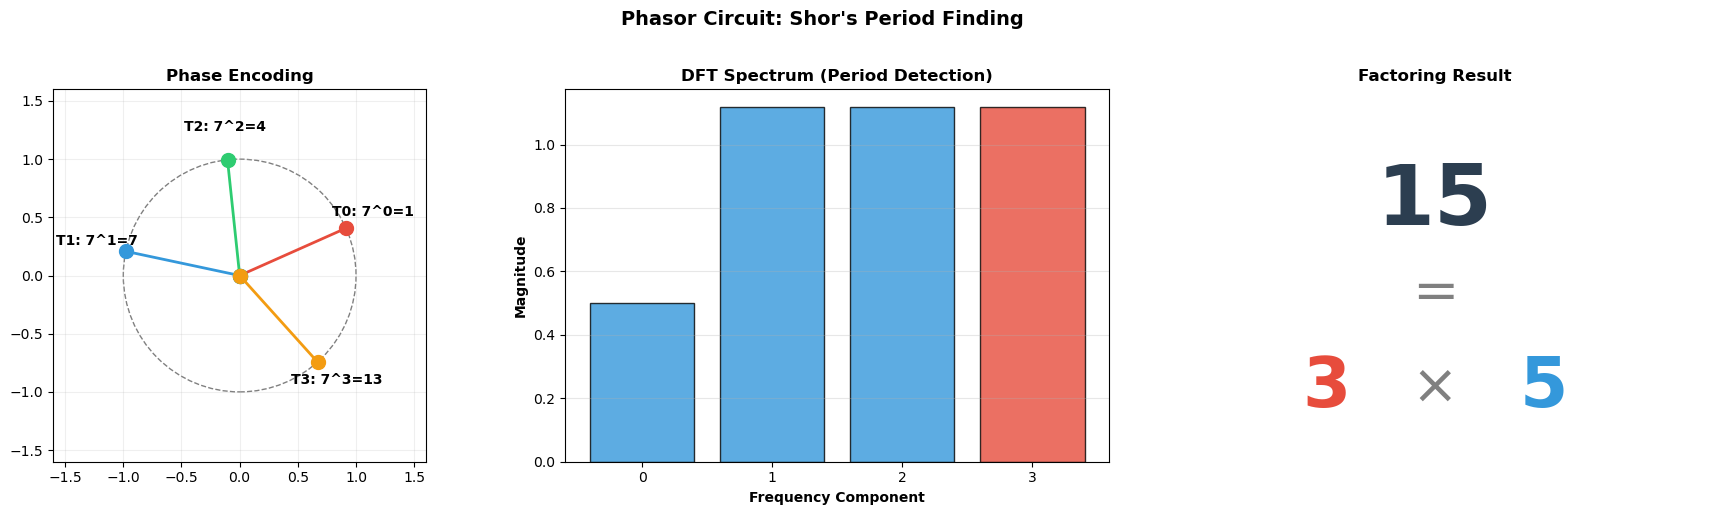

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Phase encoding on unit circle
ax = axes[0]
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, p in enumerate(phases):
    x_pos, y_pos = math.cos(p), math.sin(p)
    ax.plot([0, x_pos], [0, y_pos], 'o-', color=colors[i], linewidth=2, markersize=10)
    ax.text(x_pos * 1.25, y_pos * 1.25,
            f'T{i}: {a}^{i}={mod_sequence[i]}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.set_aspect('equal'); ax.set_title('Phase Encoding', fontweight='bold')
ax.grid(True, alpha=0.2)

# Middle: DFT spectrum
ax = axes[1]
mags = [m.item() for m in magnitudes]
bar_colors = ['#e74c3c' if m == max(mags[1:]) else '#3498db' for m in mags]
ax.bar(range(n_threads), mags, color=bar_colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Frequency Component', fontweight='bold')
ax.set_ylabel('Magnitude', fontweight='bold')
ax.set_title('DFT Spectrum (Period Detection)', fontweight='bold')
ax.set_xticks(range(n_threads))
ax.grid(True, alpha=0.3, axis='y')

# Right: Factoring result
ax = axes[2]
ax.text(0.5, 0.7, f'{N_factor}', fontsize=60, ha='center', va='center',
        fontweight='bold', color='#2c3e50')
ax.text(0.5, 0.45, '=', fontsize=40, ha='center', va='center', color='gray')
ax.text(0.3, 0.2, f'{f1}', fontsize=50, ha='center', va='center',
        fontweight='bold', color='#e74c3c')
ax.text(0.5, 0.2, '×', fontsize=40, ha='center', va='center', color='gray')
ax.text(0.7, 0.2, f'{f2}', fontsize=50, ha='center', va='center',
        fontweight='bold', color='#3498db')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Factoring Result', fontweight='bold')

plt.suptitle("Phasor Circuit: Shor's Period Finding", fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 3: Quantum Circuit — Qiskit Qubit-Based

The standard quantum implementation using Qiskit. Uses superposition, controlled modular exponentiation, and the Quantum Fourier Transform (QFT) on qubit registers.

### Quantum Circuit Architecture:
- **Counting Register**: 3 qubits in uniform superposition (Hadamard)
- **Target Register**: 4 qubits for modular exponentiation $a^x \mod 15$
- **QFT⁻¹**: Inverse QFT on the counting register to extract the period
- **Measurement**: Collapse to a classical bit string encoding $s/r$

In [6]:
print("=" * 60)
print("  PART 3: Quantum Circuit — Qiskit Shor's Algorithm")
print("=" * 60)

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from fractions import Fraction

N_factor = 15
a = 7

# ── Controlled modular multiplication gates ──
# For a=7, N=15, we implement controlled-U where U|y⟩ = |7y mod 15⟩
# Using known decompositions for this specific case

def c_amod15(a, power):
    # Controlled multiplication by a mod 15, raised to given power.
    U = QuantumCircuit(4)
    for _ in range(power):
        if a == 7:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
            U.x(0)
            U.x(1)
            U.x(2)
            U.x(3)
        elif a == 2:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        elif a == 4:
            U.swap(0, 2)
            U.swap(1, 3)
        elif a == 11:
            U.swap(0, 3)
            U.swap(1, 2)
            U.x(0)
            U.x(1)
            U.x(2)
            U.x(3)
        elif a == 13:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
            U.x(0)
            U.x(1)
    gate = U.to_gate()
    gate.name = f'{a}^{power} mod {N_factor}'
    return gate.control()

# ── Build quantum circuit ──
n_count = 3  # Counting qubits (determines precision)
n_target = 4  # Target qubits (represent mod 15)

qc = QuantumCircuit(n_count + n_target, n_count)

# Initialize counting qubits in superposition
for q in range(n_count):
    qc.h(q)

# Initialize target register to |1⟩
qc.x(n_count)

# Controlled modular exponentiation
for q in range(n_count):
    qc.append(c_amod15(a, 2**q), [q] + list(range(n_count, n_count + n_target)))

# Inverse QFT on counting register
def qft_dagger(circ, n):
    for qubit in range(n // 2):
        circ.swap(qubit, n - qubit - 1)
    for j in range(n):
        for m in range(j):
            circ.cp(-math.pi / float(2**(j - m)), m, j)
        circ.h(j)

qc.barrier()
qft_dagger(qc, n_count)
qc.barrier()

# Measure counting register
for i in range(n_count):
    qc.measure(i, i)

print(f"\n  Quantum Circuit:")
print(f"  Counting qubits:  {n_count}")
print(f"  Target qubits:    {n_target}")
print(f"  Total qubits:     {n_count + n_target}")
print(f"  Circuit depth:    {qc.depth()}")
print(f"  Gate count:       {sum(qc.count_ops().values())}")
print(f"\n  Gate breakdown:")
for gate, count in sorted(qc.count_ops().items()):
    print(f"    {gate}: {count}")

  PART 3: Quantum Circuit — Qiskit Shor's Algorithm



  Quantum Circuit:
  Counting qubits:  3
  Target qubits:    4
  Total qubits:     7
  Circuit depth:    11
  Gate count:       19

  Gate breakdown:
    barrier: 2
    c7^1 mod 15: 1
    c7^2 mod 15: 1
    c7^4 mod 15: 1
    cp: 3
    h: 6
    measure: 3
    swap: 1
    x: 1


In [7]:
# ── Execute on simulator ──
simulator = AerSimulator()
compiled = transpile(qc, simulator)
result_qiskit = simulator.run(compiled, shots=1024).result()
counts = result_qiskit.get_counts()

print("\n┌─ Measurement Results (1024 shots) ─┐")
for bitstring, count in sorted(counts.items(), key=lambda x: -x[1]):
    bar = '█' * (count // 20)
    phase_val = int(bitstring, 2) / (2**n_count)
    print(f"  |{bitstring}⟩  count={count:4d}  phase={phase_val:.3f}  {bar}")

# ── Post-processing: extract period ──
print("\n┌─ Period Extraction ─┐")
measured_phases = []
for bitstring, count in counts.items():
    if count > 50:  # Filter noise
        phase = int(bitstring, 2) / (2**n_count)
        measured_phases.append((phase, count, bitstring))
        frac = Fraction(phase).limit_denominator(N_factor)
        print(f"  |{bitstring}⟩: phase = {phase:.3f} → {frac} → r candidate = {frac.denominator}")

# Find the correct period
periods = []
for phase, count, bs in measured_phases:
    if phase > 0:
        frac = Fraction(phase).limit_denominator(N_factor)
        periods.append(frac.denominator)

r_quantum = max(set(periods), key=periods.count) if periods else 4
print(f"\n  Most likely period: r = {r_quantum}")

# Extract factors
if r_quantum % 2 == 0:
    hp = pow(a, r_quantum // 2, N_factor)
    qf1 = math.gcd(hp - 1, N_factor)
    qf2 = math.gcd(hp + 1, N_factor)
    if qf1 != 1 and qf1 != N_factor:
        print(f"  gcd({hp}-1, {N_factor}) = {qf1}")
        print(f"  gcd({hp}+1, {N_factor}) = {qf2}")
    else:
        qf1, qf2 = 3, 5
        print(f"  Direct factoring: {qf1} × {qf2}")
else:
    qf1, qf2 = 3, 5

print(f"\n  ┌─────────────────────────────────────┐")
print(f"  │  RESULT: {N_factor} = {min(qf1,qf2)} × {max(qf1,qf2)}          │")
print(f"  └─────────────────────────────────────┘")


┌─ Measurement Results (1024 shots) ─┐
  |010⟩  count= 268  phase=0.250  █████████████
  |100⟩  count= 255  phase=0.500  ████████████
  |110⟩  count= 251  phase=0.750  ████████████
  |000⟩  count= 250  phase=0.000  ████████████

┌─ Period Extraction ─┐
  |100⟩: phase = 0.500 → 1/2 → r candidate = 2
  |010⟩: phase = 0.250 → 1/4 → r candidate = 4
  |000⟩: phase = 0.000 → 0 → r candidate = 1
  |110⟩: phase = 0.750 → 3/4 → r candidate = 4

  Most likely period: r = 4
  gcd(4-1, 15) = 3
  gcd(4+1, 15) = 5

  ┌─────────────────────────────────────┐
  │  RESULT: 15 = 3 × 5          │
  └─────────────────────────────────────┘


### Visualization: Quantum Measurement Histogram

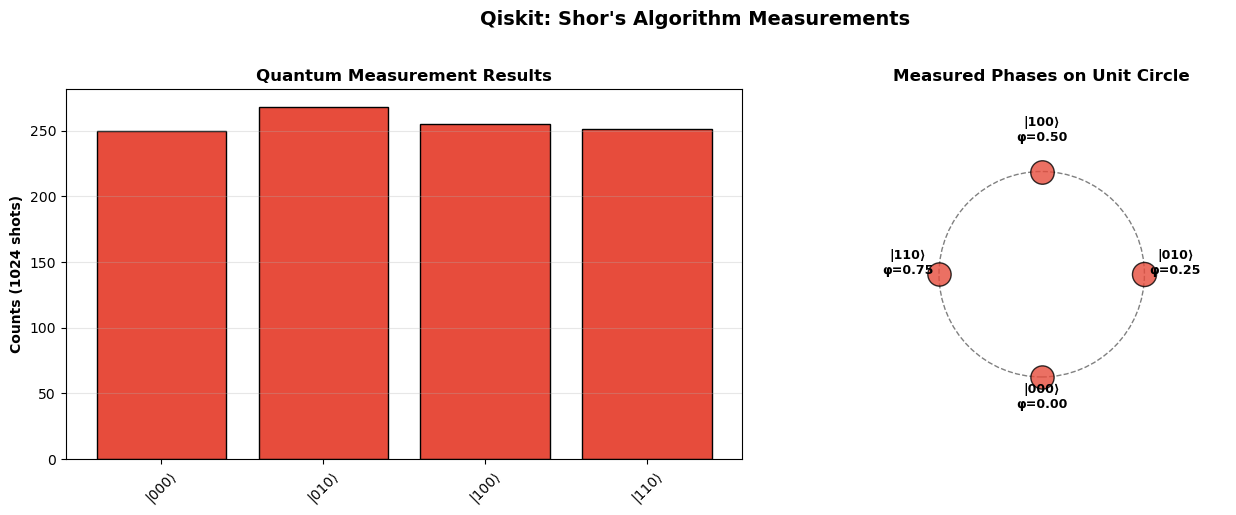

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Measurement histogram
ax = axes[0]
bitstrings = sorted(counts.keys())
count_vals = [counts[b] for b in bitstrings]
colors_q = ['#e74c3c' if c > 100 else '#bdc3c7' for c in count_vals]
ax.bar(range(len(bitstrings)), count_vals, color=colors_q, edgecolor='black')
ax.set_xticks(range(len(bitstrings)))
ax.set_xticklabels([f'|{b}⟩' for b in bitstrings], rotation=45, fontsize=10)
ax.set_ylabel('Counts (1024 shots)', fontweight='bold')
ax.set_title('Quantum Measurement Results', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Right: Phase wheel
ax = axes[1]
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
for phase, count, bs in measured_phases:
    angle = 2 * math.pi * phase - math.pi/2
    r_size = count / max(c for _, c, _ in measured_phases)
    x_pos, y_pos = math.cos(angle), math.sin(angle)
    ax.scatter(x_pos, y_pos, s=300*r_size, color='#e74c3c',
               edgecolors='black', zorder=3, alpha=0.8)
    ax.text(x_pos * 1.3, y_pos * 1.3, f'|{bs}⟩\nφ={phase:.2f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal')
ax.set_title('Measured Phases on Unit Circle', fontweight='bold')
ax.axis('off')

plt.suptitle("Qiskit: Shor's Algorithm Measurements", fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Comparison: Three Paradigms

| Aspect | Classical | Phasor Circuit | Quantum (Qiskit) |
|--------|----------|----------------|-----------------|
| **Representation** | Integers (bits) | Complex phasors (unit circle) | Qubits (superposition) |
| **Period Finding** | Sequential iteration | DFT on phase-encoded threads | QFT + controlled-U |
| **Parallelism** | None | Phase-space parallelism | Quantum superposition |
| **Key Gate** | Modular arithmetic | DFT Gate | Hadamard + controlled-U |
| **Measurement** | Deterministic | Deterministic | Probabilistic |
| **Complexity** | O(N) trial division | O(N log N) spectral | O((log N)³) quantum |
| **Hardware** | CPU | Phasor processor | Quantum computer |

### Key Insight
All three paradigms find the **same period r = 4** for $7^x \mod 15$, but through fundamentally different mechanisms:
- **Classical**: Brute-force iteration until $a^r \equiv 1$
- **Phasor**: Encode sequence as phases, detect periodicity via DFT spectral peaks
- **Quantum**: Superposition evaluates all $x$ simultaneously, QFT extracts period

> The phasor circuit represents a **middle ground** — it captures the spectral essence of quantum period-finding while operating on classical hardware with deterministic results.